In [1]:
!pip install -q SpeechRecognition

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 43.8 MB/s eta 0:00:00


In [2]:
!pip install -q kaggle

In [4]:
!mkdir -p /content/kaggle_data

!kaggle datasets download \
    -d grassknoted/asl-alphabet \
    -p /content/kaggle_data

Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
100% 1.03G/1.03G [00:13<00:00, 81.9MB/s]



In [5]:
import zipfile
import glob
import os

zip_files = glob.glob("/content/kaggle_data/*.zip")

print(zip_files)

for zip_file in zip_files:
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall("/content/asl_dataset")

print("Dataset extracted.")

['/content/kaggle_data/asl-alphabet.zip']
Dataset extracted.


In [6]:
!find /content/asl_dataset -maxdepth 4 -type d | head -50

/content/asl_dataset
/content/asl_dataset/asl_alphabet_test
/content/asl_dataset/asl_alphabet_test/asl_alphabet_test
/content/asl_dataset/asl_alphabet_train
/content/asl_dataset/asl_alphabet_train/asl_alphabet_train
/content/asl_dataset/asl_alphabet_train/asl_alphabet_train/L
/content/asl_dataset/asl_alphabet_train/asl_alphabet_train/T
/content/asl_dataset/asl_alphabet_train/asl_alphabet_train/W
/content/asl_dataset/asl_alphabet_train/asl_alphabet_train/C
/content/asl_dataset/asl_alphabet_train/asl_alphabet_train/O
/content/asl_dataset/asl_alphabet_train/asl_alphabet_train/N
/content/asl_dataset/asl_alphabet_train/asl_alphabet_train/J
/content/asl_dataset/asl_alphabet_train/asl_alphabet_train/H
/content/asl_dataset/asl_alphabet_train/asl_alphabet_train/R
/content/asl_dataset/asl_alphabet_train/asl_alphabet_train/X
/content/asl_dataset/asl_alphabet_train/asl_alphabet_train/S
/content/asl_dataset/asl_alphabet_train/asl_alphabet_train/Q
/content/asl_dataset/asl_alphabet_train/asl_alphabet

In [7]:
import tensorflow as tf
import numpy as np
import os

IMG_SIZE = 64
BATCH_SIZE = 64

LETTERS = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

class_to_index = {
    letter: i
    for i, letter in enumerate(LETTERS)
}

print(class_to_index)

{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25}


In [8]:
image_paths = []
labels = []

DATASET_PATH = "/content/asl_dataset/asl_alphabet_train/asl_alphabet_train"

for letter in LETTERS:

    folder = os.path.join(DATASET_PATH, letter)

    for file in os.listdir(folder):

        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            image_paths.append(
                os.path.join(folder, file)
            )

            labels.append(
                class_to_index[letter]
            )

print("Images:", len(image_paths))
print("Classes:", len(set(labels)))

Images: 78000
Classes: 26


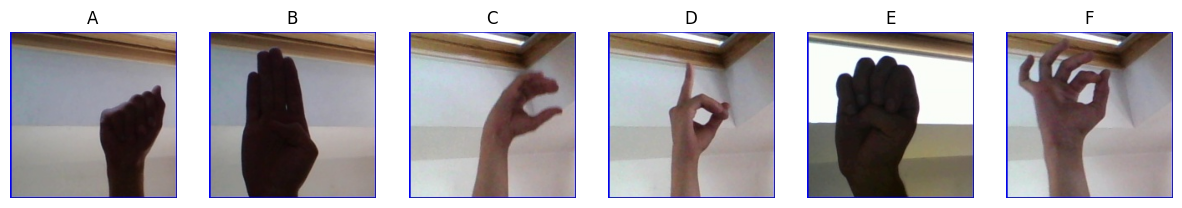

In [9]:
import matplotlib.pyplot as plt
import random

letters_to_check = ["A", "B", "C", "D", "E", "F"]

plt.figure(figsize=(15, 3))

for i, letter in enumerate(letters_to_check):

    folder = os.path.join(DATASET_PATH, letter)

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_file = random.choice(images)

    image_path = os.path.join(folder, image_file)

    image = plt.imread(image_path)

    ax = plt.subplot(1, len(letters_to_check), i + 1)

    ax.imshow(image)
    ax.set_title(letter)
    ax.axis("off")

plt.show()

In [10]:
LETTERS = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

print(LETTERS)

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [11]:
import tensorflow as tf
import numpy as np

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

In [12]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=LETTERS
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=LETTERS
)

Found 78000 files belonging to 26 classes.
Using 62400 files for training.
Found 78000 files belonging to 26 classes.
Using 15600 files for validation.


In [13]:
class_names = train_dataset.class_names

print(class_names)
print("Number of classes:", len(class_names))

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Number of classes: 26


In [14]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    AUTOTUNE
)

In [15]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

cnn_model = models.Sequential([

    layers.Input(
        shape=IMG_SIZE + (3,)
    ),

    layers.RandomFlip(
        "horizontal"
    ),

    layers.RandomRotation(
        0.05
    ),

    layers.RandomZoom(
        0.1
    ),

    layers.Lambda(
        preprocess_input
    ),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.2),

    layers.Dense(
        26,
        activation="softmax"
    )
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
cnn_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [17]:
cnn_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [ ]:
EPOCHS = 5

history = cnn_model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=EPOCHS
)

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
cnn_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [ ]:
cnn_model.save(
    "/content/asl_cnn_model.keras"
)

In [ ]:
def predict_asl_image(image_path):

    image = tf.keras.utils.load_img(
        image_path,
        target_size=IMG_SIZE
    )

    image = tf.keras.utils.img_to_array(
        image
    )

    image = np.expand_dims(
        image,
        axis=0
    )

    prediction = cnn_model.predict(
        image,
        verbose=0
    )[0]

    index = np.argmax(prediction)

    letter = class_names[index]

    confidence = prediction[index]

    return letter, float(confidence)

In [ ]:
import random
import os

test_letter = "A"

folder = os.path.join(
    DATASET_PATH,
    test_letter
)

images = [
    x for x in os.listdir(folder)
    if x.lower().endswith(
        (".jpg", ".jpeg", ".png")
    )
]

test_image = os.path.join(
    folder,
    random.choice(images)
)

prediction, confidence = predict_asl_image(
    test_image
)

print("Actual:", test_letter)
print("Predicted:", prediction)
print("Confidence:", confidence)

In [ ]:
!pip install -q nltk

In [ ]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

In [ ]:
def words_to_letters(words):

    result = []

    for word in words:

        letters = list(
            word.upper()
        )

        result.append(
            letters
        )

    return result

In [ ]:
import re
from nltk.tokenize import word_tokenize

def preprocess_text(text):

    # lowercase
    text = text.lower()

    # remove punctuation
    text = re.sub(
        r"[^a-zA-Z\s]",
        "",
        text
    )

    # tokenize
    words = word_tokenize(text)

    return words

In [ ]:
def text_to_asl_sequence(text):

    words = preprocess_text(text)

    letters = words_to_letters(words)

    return words, letters

In [ ]:
import random

def get_cnn_validated_image(letter):

    letter = letter.upper()

    folder = os.path.join(
        DATASET_PATH,
        letter
    )

    if not os.path.exists(folder):
        return None, 0.0

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    random.shuffle(images)

    # Try several candidate images
    for filename in images[:20]:

        image_path = os.path.join(
            folder,
            filename
        )

        predicted, confidence = (
            predict_asl_image(image_path)
        )

        if (
            predicted == letter
            and confidence >= 0.80
        ):

            return image_path, confidence

    return None, 0.0

In [ ]:
image_path, confidence = (
    get_cnn_validated_image("H")
)

print(image_path)
print(confidence)

In [ ]:
import matplotlib.pyplot as plt

def display_asl_sequence(text):

    words, letter_groups = (
        text_to_asl_sequence(text)
    )

    print("TEXT:")
    print(text)

    print("\nWORDS:")
    print(" | ".join(words))

    print("\nLETTERS:")

    all_letters = []

    for group in letter_groups:

        all_letters.extend(group)

    print(" → ".join(all_letters))

    print("\nGenerating ASL sequence...")

    results = []

    for letter in all_letters:

        image_path, confidence = (
            get_cnn_validated_image(letter)
        )

        if image_path:

            results.append(
                (
                    letter,
                    image_path,
                    confidence
                )
            )

    if not results:

        print("No valid ASL images found.")

        return

    # Display
    plt.figure(
        figsize=(3 * len(results), 4)
    )

    for i, (
        letter,
        image_path,
        confidence
    ) in enumerate(results):

        image = plt.imread(
            image_path
        )

        ax = plt.subplot(
            1,
            len(results),
            i + 1
        )

        ax.imshow(image)

        ax.set_title(
            f"{letter}\n{confidence:.1%}"
        )

        ax.axis("off")

    plt.show()

In [ ]:
display_asl_sequence(
    "I LOVE YOU"
)

In [ ]:
from google.colab.output import eval_js

In [ ]:
def speech_to_text():

    js_code = """

    async function recognizeSpeech() {

        const recognition =
            new webkitSpeechRecognition();

        recognition.lang = "en-US";

        recognition.continuous = false;

        recognition.interimResults = false;

        return new Promise(
            (resolve, reject) => {

                recognition.onresult =
                    function(event) {

                        const text =
                            event.results[0][0]
                            .transcript;

                        resolve(text);
                    };

                recognition.onerror =
                    function(event) {

                        reject(event.error);
                    };

                recognition.start();
            }
        );
    }

    recognizeSpeech();

    """

    return eval_js(js_code)

In [ ]:
from google.colab import output
from IPython.display import Javascript, display

display(Javascript("""
(async () => {
  try {
    const stream = await navigator.mediaDevices.getUserMedia({audio: true});
    console.log("MICROPHONE SUCCESS");
    alert("✅ Microphone is working!");
    stream.getTracks().forEach(track => track.stop());
  } catch (err) {
    console.log("MICROPHONE ERROR:", err.name, err.message);
    alert("❌ Microphone error: " + err.name + " - " + err.message);
  }
})();
"""))

In [ ]:
def speech_to_asl():

    print("================================")
    print("   SPEECH → ASL SYSTEM")
    print("================================")

    print("\n🎤 Speak now...")

    text = speech_to_text()

    print("\nRecognized speech:")
    print(text)

    words, letters = (
        text_to_asl_sequence(text)
    )

    print("\nWords:")
    print(words)

    print("\nAlphabet:")
    print(
        " → ".join(
            [
                letter
                for group in letters
                for letter in group
            ]
        )
    )

    display_asl_sequence(text)

In [ ]:
speech_to_asl()